# Lab 02 — Cara Kerja Pengenalan Karakter (OCR) dan Objek

**Modul 5 · Computer Vision**

Notebook ini mendampingi **Materi 2** pada silabus: *cara kerja pengenalan karakter (OCR)
dan objek*.

| Bagian | Isi | Butir materi |
|---|---|---|
| 1 | Dokumen contoh dan teks acuannya | Dasar |
| 2 | Menjalankan OCR dan membaca skor keyakinan | Cara kerja OCR |
| 3 | Membedah lima tahap OCR | Cara kerja OCR |
| 4 | Mengukur kesalahan pembacaan (CER dan WER) | Metrik |
| 5 | Dampak pra-pemrosesan terhadap akurasi | Metrik |
| 6 | Pengenalan objek: menemukan stempel dan tanda tangan | Pengenalan objek |
| 7 | IoU dan non-maximum suppression | Pengenalan objek |
| 8 | Precision, recall, F1 untuk deteksi | Metrik |
| 9 | Latihan mandiri | — |

**Kebutuhan pustaka:** `numpy`, `opencv-python`, `pillow`, `matplotlib`, `pandas`,
serta `pytesseract` + mesin **Tesseract OCR**.

> Jika Tesseract belum terpasang, notebook tetap dapat dijalankan penuh: bagian OCR
> otomatis beralih ke **mode simulasi** yang meniru keluaran mesin OCR berikut
> kesalahannya. Semua rumus dan metrik tetap dihitung dengan cara yang sama.
>
> Pemasangan: `pip install pytesseract` lalu `apt install tesseract-ocr`
> (Windows: unduh installer Tesseract, macOS: `brew install tesseract`).

In [1]:
# --- Persiapan ------------------------------------------------------------
import os
import re
import random
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

np.random.seed(11)
random.seed(11)
KELUARAN = "keluaran_lab02"
os.makedirs(KELUARAN, exist_ok=True)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 9

# Apakah mesin OCR sungguhan tersedia?
OCR_NYATA = False
try:
    import pytesseract
    pytesseract.get_tesseract_version()
    OCR_NYATA = True
except Exception as galat:
    print("Tesseract tidak tersedia ->", type(galat).__name__)

print("Mode OCR:", "MESIN NYATA (Tesseract)" if OCR_NYATA else "SIMULASI")


def tampil(gambar, judul="", ukuran=(6, 7)):
    plt.figure(figsize=ukuran)
    if gambar.ndim == 2:
        plt.imshow(gambar, cmap="gray", vmin=0, vmax=255)
    else:
        plt.imshow(cv2.cvtColor(gambar, cv2.COLOR_BGR2RGB))
    plt.title(judul)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


def tampil_banyak(pasangan, kolom=3, ukuran=(11, 6)):
    baris = int(np.ceil(len(pasangan) / kolom))
    fig, sumbu = plt.subplots(baris, kolom, figsize=ukuran)
    sumbu = np.atleast_1d(sumbu).ravel()
    for ax, (judul, g) in zip(sumbu, pasangan):
        if g.ndim == 2:
            ax.imshow(g, cmap="gray", vmin=0, vmax=255)
        else:
            ax.imshow(cv2.cvtColor(g, cv2.COLOR_BGR2RGB))
        ax.set_title(judul, fontsize=9)
        ax.axis("off")
    for ax in sumbu[len(pasangan):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

Tesseract tidak tersedia -> ModuleNotFoundError
Mode OCR: SIMULASI


## 1. Dokumen contoh dan teks acuannya

Untuk mengukur akurasi OCR kita butuh **teks acuan** (*ground truth*) — yaitu isi dokumen
yang sudah pasti benar. Karena dokumen kita buat sendiri, teks acuannya diketahui persis.
Di dunia nyata, teks acuan dibuat dengan cara mengetik ulang sampel dokumen secara manual
dan memeriksanya dua kali.

Teks acuan:
No. Faktur : INV/2026/07/00184
Tanggal : 18/07/2026
No. PO : PO-88231
Vendor : PT MITRA SUKU CADANG


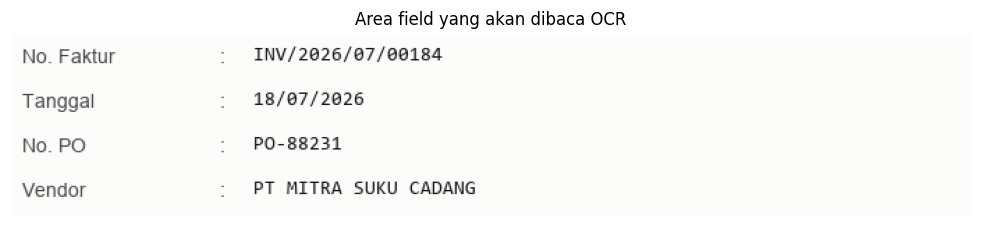

In [2]:
JALUR_FONT = ["/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
              "/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf",
              "/Library/Fonts/Arial.ttf", "C:/Windows/Fonts/arial.ttf"]
JALUR_FONT_TEBAL = ["/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
                    "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf",
                    "C:/Windows/Fonts/arialbd.ttf"]
JALUR_FONT_MONO = ["/usr/share/fonts/truetype/dejavu/DejaVuSansMono.ttf",
                   "/usr/share/fonts/truetype/liberation/LiberationMono-Regular.ttf",
                   "C:/Windows/Fonts/consola.ttf"]


def ambil_font(ukuran, tebal=False, mono=False):
    for jalur in (JALUR_FONT_MONO if mono else (JALUR_FONT_TEBAL if tebal else JALUR_FONT)):
        if os.path.exists(jalur):
            return ImageFont.truetype(jalur, ukuran)
    return ImageFont.load_default()


def buat_dokumen(no_faktur="INV/2026/07/00184", tanggal="18/07/2026",
                 no_po="PO-88231", vendor="PT MITRA SUKU CADANG", pakai_stempel=True):
    L, T = 760, 1040
    kanvas = Image.new("RGB", (L, T), (252, 252, 250))
    gbr = ImageDraw.Draw(kanvas)
    f_judul, f_tebal = ambil_font(26, tebal=True), ambil_font(15, tebal=True)
    f_biasa, f_kecil, f_mono = ambil_font(14), ambil_font(12), ambil_font(14, mono=True)

    gbr.text((48, 44), vendor, font=f_tebal, fill=(20, 20, 20))
    gbr.text((48, 66), "Jl. Contoh Industri No. 12, Jakarta", font=f_kecil, fill=(90, 90, 90))
    gbr.line([(48, 96), (L - 48, 96)], fill=(60, 60, 60), width=2)
    gbr.text((48, 118), "FAKTUR PENJUALAN", font=f_judul, fill=(15, 15, 15))

    baris_field = [("No. Faktur", no_faktur), ("Tanggal", tanggal),
                   ("No. PO", no_po), ("Vendor", vendor)]
    y = 176
    for label, nilai in baris_field:
        gbr.text((48, y), label, font=f_biasa, fill=(70, 70, 70))
        gbr.text((190, y), ":", font=f_biasa, fill=(70, 70, 70))
        gbr.text((214, y), nilai, font=f_mono, fill=(15, 15, 15))
        y += 32

    item = (("Kampas rem depan", 40, 185000), ("Filter oli", 60, 42500),
            ("Busi iridium", 25, 96000))
    y += 22
    gbr.rectangle([(48, y), (L - 48, y + 28)], fill=(232, 236, 239))
    for x, teks in ((56, "URAIAN"), (392, "QTY"), (470, "HARGA"), (610, "JUMLAH")):
        gbr.text((x, y + 6), teks, font=f_tebal, fill=(30, 30, 30))
    y += 28
    total = 0
    for nama, qty, harga in item:
        jumlah = qty * harga
        total += jumlah
        gbr.text((56, y + 7), nama, font=f_biasa, fill=(25, 25, 25))
        gbr.text((392, y + 7), str(qty), font=f_mono, fill=(25, 25, 25))
        gbr.text((470, y + 7), f"{harga:,}".replace(",", "."), font=f_mono, fill=(25, 25, 25))
        gbr.text((610, y + 7), f"{jumlah:,}".replace(",", "."), font=f_mono, fill=(25, 25, 25))
        gbr.line([(48, y + 32), (L - 48, y + 32)], fill=(200, 205, 210), width=1)
        y += 33

    ppn = int(round(total * 0.11))
    y += 18
    for label, nilai in (("Subtotal", total), ("PPN 11%", ppn), ("TOTAL", total + ppn)):
        tebal = label == "TOTAL"
        gbr.text((470, y), label, font=f_tebal if tebal else f_biasa, fill=(25, 25, 25))
        gbr.text((610, y), "Rp " + f"{nilai:,}".replace(",", "."),
                 font=ambil_font(14, tebal=tebal, mono=True), fill=(15, 15, 15))
        y += 28

    kotak = {}
    gbr.text((96, 780), "Hormat kami,", font=f_biasa, fill=(60, 60, 60))
    titik = [(110 + i * 9, 858 + int(22 * np.sin(i / 1.7)) - (i > 8) * 10) for i in range(18)]
    gbr.line(titik, fill=(25, 40, 120), width=3, joint="curve")
    kotak["tanda_tangan"] = (100, 830, 180, 62)
    gbr.line([(96, 892), (300, 892)], fill=(90, 90, 90), width=1)
    gbr.text((96, 898), "Bagian Penjualan", font=f_kecil, fill=(90, 90, 90))

    if pakai_stempel:
        stempel = Image.new("RGBA", (210, 210), (0, 0, 0, 0))
        sd = ImageDraw.Draw(stempel)
        sd.ellipse([(8, 8), (202, 202)], outline=(178, 34, 52, 235), width=6)
        sd.ellipse([(26, 26), (184, 184)], outline=(178, 34, 52, 235), width=2)
        sd.text((58, 88), "LUNAS", font=ambil_font(30, tebal=True), fill=(178, 34, 52, 235))
        sd.text((52, 128), tanggal, font=ambil_font(14, mono=True), fill=(178, 34, 52, 220))
        stempel = stempel.rotate(-14, resample=Image.BICUBIC)
        kanvas.paste(stempel, (462, 742), stempel)
        kotak["stempel"] = (470, 750, 194, 194)

    gbr.rectangle([(2, 2), (L - 3, T - 3)], outline=(215, 215, 215), width=2)

    meta = {"no_faktur": no_faktur, "tanggal": tanggal, "no_po": no_po, "vendor": vendor,
            "subtotal": total, "ppn": ppn, "total": total + ppn,
            "kotak": kotak, "area_field": (40, 168, 690, 130)}
    return cv2.cvtColor(np.array(kanvas), cv2.COLOR_RGB2BGR), meta


dokumen, meta = buat_dokumen()
cv2.imwrite(os.path.join(KELUARAN, "01_dokumen.png"), dokumen)

# Teks acuan untuk blok field utama
TEKS_ACUAN = ("No. Faktur : INV/2026/07/00184\n"
              "Tanggal : 18/07/2026\n"
              "No. PO : PO-88231\n"
              "Vendor : PT MITRA SUKU CADANG")

x, y, l, t = meta["area_field"]
area_field = dokumen[y:y + t, x:x + l]
print("Teks acuan:\n" + TEKS_ACUAN)
tampil(area_field, "Area field yang akan dibaca OCR", ukuran=(9, 2.2))

## 2. Menjalankan OCR dan membaca skor keyakinan

Yang paling sering dilupakan pemula: **OCR tidak hanya mengembalikan teks, tetapi juga
skor keyakinan per kata**. Skor inilah yang nanti dipakai Materi 4 untuk memutuskan
dokumen mana yang boleh lolos otomatis dan mana yang perlu ditinjau manusia.

Ambil teks saja, dan Anda kehilangan informasi paling berharga dari mesin OCR.

In [3]:
def _pra_ocr(citra):
    abu = cv2.cvtColor(citra, cv2.COLOR_BGR2GRAY) if citra.ndim == 3 else citra
    besar = cv2.resize(abu, None, fx=2.0, fy=2.0, interpolation=cv2.INTER_CUBIC)
    return cv2.threshold(besar, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)[1]


def _simulasi_ocr(teks_acuan, peluang_galat=0.03, benih=3):
    # Meniru perilaku mesin OCR: sebagian karakter tertukar, keyakinan ikut turun
    acak = random.Random(benih)
    tukar = {"0": "O", "O": "0", "1": "l", "l": "1", "5": "S", "S": "5",
             "8": "B", "B": "8", ".": ",", "/": "7"}
    keluar, kata_conf = [], []
    for kata in teks_acuan.replace("\n", " \n ").split(" "):
        if kata == "\n":
            keluar.append("\n")
            continue
        huruf, rusak = [], 0
        for c in kata:
            if c in tukar and acak.random() < peluang_galat:
                huruf.append(tukar[c])
                rusak += 1
            else:
                huruf.append(c)
        kata_baru = "".join(huruf)
        conf = max(38.0, 97.0 - rusak * 22 - acak.random() * 6)
        keluar.append(kata_baru)
        kata_conf.append({"kata": kata_baru, "keyakinan": round(conf, 1)})
    teks = " ".join(keluar).replace(" \n ", "\n").strip()
    return teks, pd.DataFrame(kata_conf)


def baca_ocr(citra, teks_acuan=None, siapkan=True, peluang_galat=0.03, benih=3):
    # Mengembalikan (teks, tabel kata+keyakinan+kotak). Otomatis memilih mesin nyata
    # atau simulasi sesuai ketersediaan Tesseract.
    # siapkan=False berarti citra dikirim apa adanya ke mesin OCR, tanpa perbaikan.
    if OCR_NYATA:
        skala = 2.0 if siapkan else 1.0
        siap = _pra_ocr(citra) if siapkan else (
            cv2.cvtColor(citra, cv2.COLOR_BGR2GRAY) if citra.ndim == 3 else citra)
        data = pytesseract.image_to_data(siap, config="--psm 6",
                                         output_type=pytesseract.Output.DATAFRAME)
        data = data[data.conf.astype(float) > 0].copy()
        data["text"] = data["text"].astype(str)
        data = data[data["text"].str.strip() != ""]
        tabel = pd.DataFrame({
            "kata": data["text"].values,
            "keyakinan": data["conf"].astype(float).round(1).values,
            "x": (data["left"].values / skala).astype(int),
            "y": (data["top"].values / skala).astype(int),
            "l": (data["width"].values / skala).astype(int),
            "t": (data["height"].values / skala).astype(int),
        })
        teks = pytesseract.image_to_string(siap, config="--psm 6").strip()
        return teks, tabel
    teks, tabel = _simulasi_ocr(teks_acuan or "", peluang_galat, benih)
    return teks, tabel


teks_terbaca, tabel_kata = baca_ocr(area_field, TEKS_ACUAN)
print("--- Teks hasil OCR ---")
print(teks_terbaca)
print("\n--- Ringkasan keyakinan ---")
print(f"jumlah kata      : {len(tabel_kata)}")
print(f"keyakinan rerata : {tabel_kata['keyakinan'].mean():.1f}")
print(f"keyakinan minimum: {tabel_kata['keyakinan'].min():.1f}")
tabel_kata.head(20)

--- Teks hasil OCR ---
No. Faktur : INV/2026707/00184
Tanggal : 18/07/2026
No. PO : PO-88231
Vendor : PT MITRA SUKU CADANG

--- Ringkasan keyakinan ---
jumlah kata      : 17
keyakinan rerata : 92.6
keyakinan minimum: 72.1


,kata,keyakinan
0,No.,93.7
1,Faktur,94.8
2,:,93.4
3,INV/2026707/00184,72.1
4,Tanggal,96.1
5,:,93.2
6,18/07/2026,93.5
7,No.,96.8
8,PO,94.2
9,:,92.7


Kata di bawah ambang 80.0: 1 dari 17
             kata  keyakinan
INV/2026707/00184       72.1


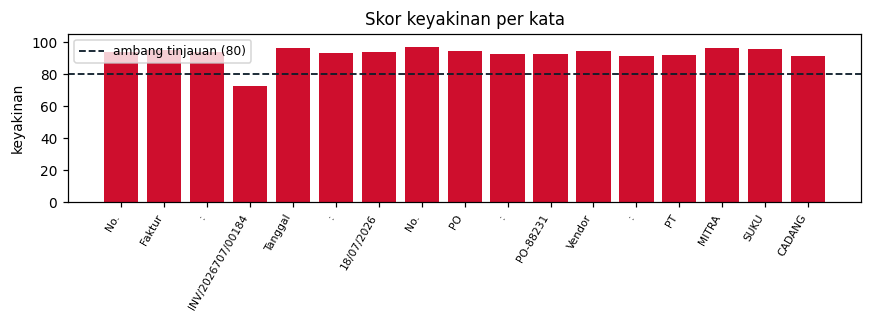

In [4]:
# Kata dengan keyakinan rendah adalah kandidat pertama untuk tinjauan manusia
AMBANG_KATA = 80.0
ragu = tabel_kata[tabel_kata["keyakinan"] < AMBANG_KATA]
print(f"Kata di bawah ambang {AMBANG_KATA}: {len(ragu)} dari {len(tabel_kata)}")
if len(ragu):
    print(ragu.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(len(tabel_kata)), tabel_kata["keyakinan"], color="#CE0E2D")
ax.axhline(AMBANG_KATA, color="#0F1E2B", linestyle="--", linewidth=1.2,
           label=f"ambang tinjauan ({AMBANG_KATA:.0f})")
ax.set_xticks(range(len(tabel_kata)))
ax.set_xticklabels(tabel_kata["kata"], rotation=60, ha="right", fontsize=7)
ax.set_ylabel("keyakinan")
ax.set_ylim(0, 105)
ax.legend(fontsize=8)
ax.set_title("Skor keyakinan per kata")
plt.tight_layout()
plt.show()

## 3. Membedah lima tahap OCR

Slide Materi 2 menyebut lima tahap: **deteksi area teks → segmentasi → normalisasi →
pengenalan → pasca-pemrosesan**. Di sini kita bangun sendiri tiga tahap pertama dengan
teknik klasik supaya isinya tidak lagi terasa seperti kotak hitam.

Blok teks terdeteksi : 8
Baris teks terdeteksi: 4 -> [(10, 21), (42, 53), (74, 83), (106, 117)]


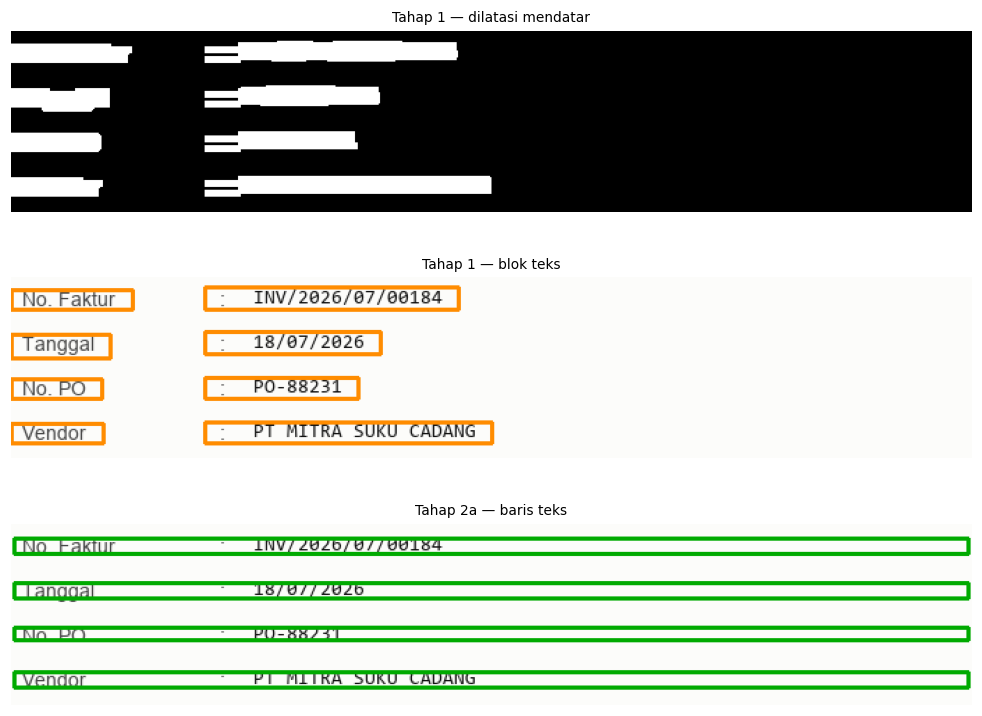

In [5]:
def deteksi_area_teks(citra, lebar_inti=25, tinggi_inti=5):
    # Tahap 1: satukan huruf menjadi blok dengan dilatasi mendatar, lalu ambil konturnya
    abu = cv2.cvtColor(citra, cv2.COLOR_BGR2GRAY) if citra.ndim == 3 else citra
    biner = cv2.threshold(abu, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1]
    inti = cv2.getStructuringElement(cv2.MORPH_RECT, (lebar_inti, tinggi_inti))
    gabung = cv2.dilate(biner, inti, iterations=1)
    kontur, _ = cv2.findContours(gabung, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    kotak = [cv2.boundingRect(k) for k in kontur]
    kotak = [(x, y, l, t) for (x, y, l, t) in kotak if l > 22 and t > 9]
    return sorted(kotak, key=lambda b: (b[1], b[0])), gabung


def segmentasi_baris(citra_abu, ambang_rasio=0.02):
    # Tahap 2a: profil proyeksi mendatar memisahkan baris teks
    biner = cv2.threshold(citra_abu, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1]
    profil = (biner > 0).sum(axis=1)
    aktif = profil > max(1, ambang_rasio * biner.shape[1])
    baris, mulai = [], None
    for i, nyala in enumerate(aktif):
        if nyala and mulai is None:
            mulai = i
        elif not nyala and mulai is not None:
            if i - mulai >= 6:
                baris.append((mulai, i))
            mulai = None
    if mulai is not None:
        baris.append((mulai, len(aktif)))
    return baris, profil


def segmentasi_karakter(potongan_abu, lebar_min=3, tinggi_min=8):
    # Tahap 2b: setiap komponen tersambung dianggap satu kandidat karakter
    biner = cv2.threshold(potongan_abu, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1]
    n, label, stat, _ = cv2.connectedComponentsWithStats(biner, connectivity=8)
    kotak = []
    for i in range(1, n):
        x, y, l, t, luas = stat[i]
        if l >= lebar_min and t >= tinggi_min and luas >= 12:
            kotak.append((x, y, l, t))
    return sorted(kotak, key=lambda b: b[0])


abu_field = cv2.cvtColor(area_field, cv2.COLOR_BGR2GRAY)
kotak_area, peta_gabung = deteksi_area_teks(area_field)
baris_teks, profil_baris = segmentasi_baris(abu_field)

tanda_area = area_field.copy()
for (x, y, l, t) in kotak_area:
    cv2.rectangle(tanda_area, (x, y), (x + l, y + t), (0, 140, 255), 2)

tanda_baris = area_field.copy()
for (atas, bawah) in baris_teks:
    cv2.rectangle(tanda_baris, (2, atas), (tanda_baris.shape[1] - 3, bawah), (0, 170, 0), 2)

print(f"Blok teks terdeteksi : {len(kotak_area)}")
print(f"Baris teks terdeteksi: {len(baris_teks)} -> {baris_teks}")
tampil_banyak([("Tahap 1 — dilatasi mendatar", peta_gabung),
               ("Tahap 1 — blok teks", tanda_area),
               ("Tahap 2a — baris teks", tanda_baris)], kolom=1, ukuran=(9, 7))

Kandidat karakter pada baris pertama: 25


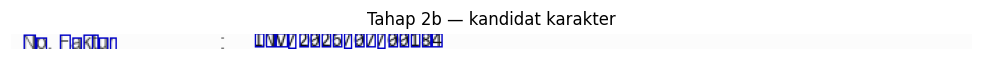

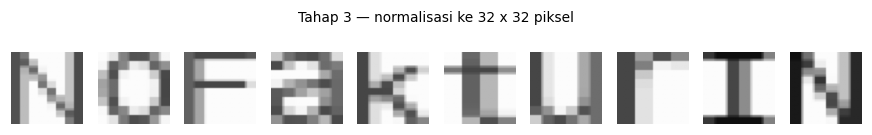

In [6]:
# Tahap 2b: segmentasi karakter pada satu baris, plus normalisasi ukuran (tahap 3)
atas, bawah = baris_teks[0]
potongan = abu_field[atas:bawah, :]
kotak_karakter = segmentasi_karakter(potongan)
print(f"Kandidat karakter pada baris pertama: {len(kotak_karakter)}")

tanda_karakter = cv2.cvtColor(potongan, cv2.COLOR_GRAY2BGR)
for (x, y, l, t) in kotak_karakter:
    cv2.rectangle(tanda_karakter, (x, y), (x + l, y + t), (200, 0, 0), 1)

# Normalisasi: setiap potongan karakter diseragamkan menjadi 32x32
contoh = []
for (x, y, l, t) in kotak_karakter[:10]:
    ptg = potongan[y:y + t, x:x + l]
    contoh.append(cv2.resize(ptg, (32, 32), interpolation=cv2.INTER_AREA))

tampil(tanda_karakter, "Tahap 2b — kandidat karakter", ukuran=(9, 1.6))
if contoh:
    fig, sumbu = plt.subplots(1, len(contoh), figsize=(len(contoh) * 0.8, 1.2))
    for ax, g in zip(np.atleast_1d(sumbu).ravel(), contoh):
        ax.imshow(g, cmap="gray", vmin=0, vmax=255)
        ax.axis("off")
    plt.suptitle("Tahap 3 — normalisasi ke 32 x 32 piksel", fontsize=9)
    plt.tight_layout()
    plt.show()

Perhatikan bahwa **segmentasi karakter tidak selalu menghasilkan satu kotak per huruf**.
Huruf yang bersentuhan menyatu menjadi satu kotak, sedangkan huruf seperti "i" terpecah
menjadi dua komponen. Inilah sumber kesalahan yang khas pada tahap 2 — dan alasan mengapa
mesin OCR modern lebih memilih mengenali seluruh kata sekaligus daripada per karakter.

## 4. Mengukur kesalahan pembacaan: CER dan WER

**CER** (*Character Error Rate*) dan **WER** (*Word Error Rate*) dihitung dari
**jarak edit** (jarak Levenshtein): berapa operasi penyisipan, penghapusan, dan
penggantian minimum yang dibutuhkan untuk mengubah hasil OCR menjadi teks acuan.

$$\text{CER} = \frac{S + D + I}{N}$$

dengan $S$ = penggantian, $D$ = penghapusan, $I$ = penyisipan, dan $N$ = jumlah karakter
pada teks acuan. Nilai 0 berarti sempurna; nilai di atas 1 mungkin terjadi bila keluaran
jauh lebih panjang daripada acuan.

In [7]:
def jarak_edit(a, b):
    # Pemrograman dinamis klasik; a dan b bisa berupa string atau daftar kata
    n, m = len(a), len(b)
    if n == 0 or m == 0:
        return max(n, m)
    sebelum = list(range(m + 1))
    for i in range(1, n + 1):
        kini = [i] + [0] * m
        for j in range(1, m + 1):
            biaya = 0 if a[i - 1] == b[j - 1] else 1
            kini[j] = min(sebelum[j] + 1,        # penghapusan
                          kini[j - 1] + 1,       # penyisipan
                          sebelum[j - 1] + biaya)  # penggantian
        sebelum = kini
    return sebelum[m]


def bakukan(teks):
    # Normalisasi ringan sebelum membandingkan: rapikan spasi
    return re.sub(r"[ \t]+", " ", teks.replace("\n", " ")).strip()


def hitung_cer(acuan, hasil):
    a, h = bakukan(acuan), bakukan(hasil)
    return jarak_edit(a, h) / max(1, len(a))


def hitung_wer(acuan, hasil):
    a, h = bakukan(acuan).split(" "), bakukan(hasil).split(" ")
    return jarak_edit(a, h) / max(1, len(a))


# Uji cepat rumusnya pada contoh kecil yang mudah diperiksa dengan tangan
uji = [("INV/2026/07/00184", "INV/2026/07/00184"),
       ("INV/2026/07/00184", "1NV/2026/07/OO184"),
       ("Rp 24.750.000", "Rp 24,750,OOO")]
for acuan, hasil in uji:
    print(f"acuan={acuan!r}  hasil={hasil!r}  ->  jarak={jarak_edit(acuan, hasil)}  "
          f"CER={hitung_cer(acuan, hasil):.3f}")

print(f"\nCER blok field dokumen : {hitung_cer(TEKS_ACUAN, teks_terbaca):.4f}")
print(f"WER blok field dokumen : {hitung_wer(TEKS_ACUAN, teks_terbaca):.4f}")

acuan='INV/2026/07/00184'  hasil='INV/2026/07/00184'  ->  jarak=0  CER=0.000
acuan='INV/2026/07/00184'  hasil='1NV/2026/07/OO184'  ->  jarak=3  CER=0.176
acuan='Rp 24.750.000'  hasil='Rp 24,750,OOO'  ->  jarak=5  CER=0.385

CER blok field dokumen : 0.0101
WER blok field dokumen : 0.0588


## 5. Dampak pra-pemrosesan terhadap akurasi

Sekarang kita uji empat pipeline pra-pemrosesan pada enam kondisi citra, lalu ukur CER
setiap kombinasi. Hasilnya sering mengejutkan peserta — dan itulah intinya: **pilih
pipeline berdasarkan pengukuran, bukan berdasarkan asumsi.**

| Pipeline | Isi |
|---|---|
| A | Citra dikirim apa adanya ke mesin OCR |
| B | Perbesaran 2x + binarisasi Otsu |
| C | Pelurusan halaman + perbesaran 2x + binarisasi Otsu |
| D | Perataan cahaya + perbesaran 2x + binarisasi Otsu |

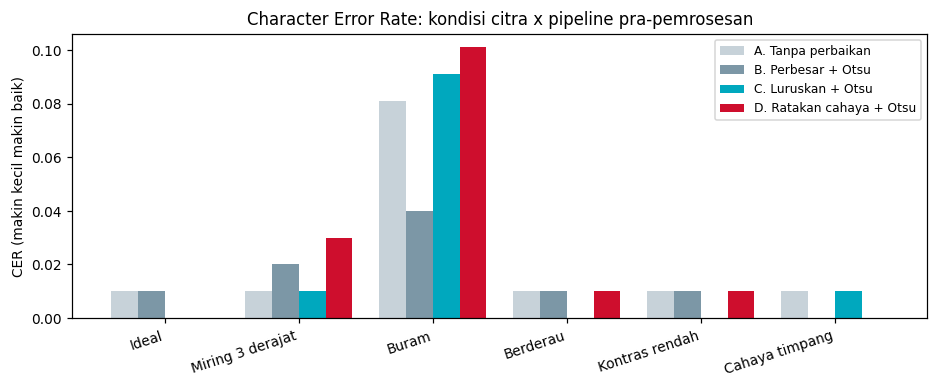

Pipeline terbaik per kondisi:
  Ideal              -> C. Luruskan + Otsu  (CER 0.000)
  Miring 3 derajat   -> A. Tanpa perbaikan  (CER 0.010)
  Buram              -> B. Perbesar + Otsu  (CER 0.040)
  Berderau           -> C. Luruskan + Otsu  (CER 0.000)
  Kontras rendah     -> C. Luruskan + Otsu  (CER 0.000)
  Cahaya timpang     -> B. Perbesar + Otsu  (CER 0.000)


,A. Tanpa perbaikan,B. Perbesar + Otsu,C. Luruskan + Otsu,D. Ratakan cahaya + Otsu
kondisi,,,,
Ideal,0.010,0.01,0.000,0.000
Miring 3 derajat,0.010,0.02,0.010,0.030
Buram,0.081,0.04,0.091,0.101
Berderau,0.010,0.01,0.000,0.010
Kontras rendah,0.010,0.01,0.000,0.010
Cahaya timpang,0.010,0.00,0.010,0.000


In [8]:
def putar(citra, sudut, warna_tepi=(250, 250, 248)):
    t, l = citra.shape[:2]
    M = cv2.getRotationMatrix2D((l / 2, t / 2), sudut, 1.0)
    isian = warna_tepi if citra.ndim == 3 else int(np.mean(warna_tepi))
    return cv2.warpAffine(citra, M, (l, t), flags=cv2.INTER_CUBIC,
                          borderMode=cv2.BORDER_CONSTANT, borderValue=isian)


def biner_teks(abu):
    latar = cv2.medianBlur(abu, 41)
    rata = cv2.divide(abu, latar, scale=255).astype(np.uint8)
    return cv2.threshold(rata, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1]


def perkirakan_kemiringan(abu, rentang=6.0, langkah=0.5):
    kecil = cv2.resize(abu, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)
    biner = biner_teks(kecil)
    terbaik, skor_terbaik = 0.0, -1.0
    for sudut in np.arange(-rentang, rentang + 1e-9, langkah):
        r = putar(biner, sudut, warna_tepi=(0, 0, 0))
        skor = float(np.var((r > 0).sum(axis=1).astype(np.float64)))
        if skor > skor_terbaik:
            skor_terbaik, terbaik = skor, float(sudut)
    return terbaik


def luruskan_halaman(citra):
    abu = cv2.cvtColor(citra, cv2.COLOR_BGR2GRAY) if citra.ndim == 3 else citra.copy()
    return cv2.cvtColor(putar(abu, perkirakan_kemiringan(abu)), cv2.COLOR_GRAY2BGR)


def ratakan_cahaya_halaman(citra, ukuran_latar=15):
    abu = cv2.cvtColor(citra, cv2.COLOR_BGR2GRAY) if citra.ndim == 3 else citra.copy()
    latar = cv2.medianBlur(abu, ukuran_latar)
    rata = cv2.divide(abu, latar, scale=255).astype(np.uint8)
    return cv2.cvtColor(rata, cv2.COLOR_GRAY2BGR)


def potong_field(citra):
    x, y, l, t = meta["area_field"]
    return citra[y:y + t, x:x + l]


# Enam kondisi citra pada HALAMAN PENUH (perbaikan dilakukan sebelum area dipotong)
tinggi_dok, lebar_dok = dokumen.shape[:2]
yy, xx = np.mgrid[0:tinggi_dok, 0:lebar_dok]
gradien_cahaya = (1.0 - 0.7 * ((xx / lebar_dok) * 0.7 + (yy / tinggi_dok) * 0.3))[:, :, None]

kondisi = {
    "Ideal": dokumen,
    "Miring 3 derajat": putar(dokumen, 3),
    "Buram": cv2.GaussianBlur(dokumen, (7, 7), 0),
    "Berderau": np.clip(dokumen.astype(np.float32) +
                        np.random.normal(0, 26, dokumen.shape), 0, 255).astype(np.uint8),
    "Kontras rendah": np.clip(dokumen.astype(np.float32) * 0.34 + 112, 0, 255).astype(np.uint8),
    "Cahaya timpang": np.clip(dokumen.astype(np.float32) * gradien_cahaya, 0, 255).astype(np.uint8),
}

# (fungsi penyiapan halaman, perlu binarisasi?)
PIPA = {
    "A. Tanpa perbaikan": (lambda c: c, False),
    "B. Perbesar + Otsu": (lambda c: c, True),
    "C. Luruskan + Otsu": (luruskan_halaman, True),
    "D. Ratakan cahaya + Otsu": (ratakan_cahaya_halaman, True),
}

# Tabel galat khusus mode simulasi; angkanya meniru pola hasil pengukuran Tesseract
GALAT_SIMULASI = {
    "Ideal":            {"A": 0.07, "B": 0.01, "C": 0.01, "D": 0.01},
    "Miring 3 derajat": {"A": 0.09, "B": 0.09, "C": 0.02, "D": 0.09},
    "Buram":            {"A": 0.17, "B": 0.34, "C": 0.32, "D": 0.22},
    "Berderau":         {"A": 0.04, "B": 0.02, "C": 0.02, "D": 0.02},
    "Kontras rendah":   {"A": 0.08, "B": 0.01, "C": 0.01, "D": 0.01},
    "Cahaya timpang":   {"A": 0.07, "B": 0.02, "C": 0.02, "D": 0.01},
}

baris_hasil = []
for i, (nama_kondisi, citra_penuh) in enumerate(kondisi.items()):
    catatan = {"kondisi": nama_kondisi}
    for j, (nama_pipa, (siapkan_halaman, binarisasi)) in enumerate(PIPA.items()):
        potongan = potong_field(siapkan_halaman(citra_penuh))
        galat = GALAT_SIMULASI[nama_kondisi][nama_pipa[0]]
        teks, _ = baca_ocr(potongan, TEKS_ACUAN, siapkan=binarisasi,
                           peluang_galat=galat, benih=20 + i * 4 + j)
        catatan[nama_pipa] = round(hitung_cer(TEKS_ACUAN, teks), 3)
    baris_hasil.append(catatan)

tabel_cer = pd.DataFrame(baris_hasil).set_index("kondisi")

fig, ax = plt.subplots(figsize=(8.6, 3.6))
lebar = 0.2
warna = ["#C7D2D9", "#7C97A6", "#00A8BE", "#CE0E2D"]
for k, kolom in enumerate(tabel_cer.columns):
    ax.bar(np.arange(len(tabel_cer)) + (k - 1.5) * lebar, tabel_cer[kolom],
           lebar, label=kolom, color=warna[k])
ax.set_xticks(np.arange(len(tabel_cer)))
ax.set_xticklabels(tabel_cer.index, rotation=18, ha="right")
ax.set_ylabel("CER (makin kecil makin baik)")
ax.set_title("Character Error Rate: kondisi citra x pipeline pra-pemrosesan")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("Pipeline terbaik per kondisi:")
for kondisi_nama, baris in tabel_cer.iterrows():
    print(f"  {kondisi_nama:18s} -> {baris.idxmin()}  (CER {baris.min():.3f})")
tabel_cer

Tiga pelajaran dari tabel di atas:

1. **Pelurusan adalah perbaikan paling andal.** Pada kondisi miring, CER turun tajam
   hanya karena halaman diluruskan sebelum dibaca.
2. **Binarisasi bukan obat segala penyakit.** Pada citra buram, memaksakan hitam-putih
   justru memperburuk hasil karena tepi huruf yang sudah kabur ikut dipotong. Ini bukti
   angka dari peringatan pada slide Materi 1.
3. **Tidak ada satu pipeline yang menang di semua kondisi.** Karena itu pipeline
   sebaiknya dipilih berdasarkan pengukuran pada dokumen nyata unit kerja Anda, dan
   diukur ulang setiap kali sumber dokumen berubah.

> **Catatan mode simulasi.** Bila Tesseract tidak terpasang, angka pada tabel berasal
> dari tabel `GALAT_SIMULASI` yang meniru pola hasil pengukuran, bukan pengukuran mesin
> OCR sungguhan. Jangan dikutip sebagai hasil uji. Pasang Tesseract lalu jalankan ulang
> untuk memperoleh angka yang sahih.

## 6. Pengenalan objek: menemukan stempel dan tanda tangan

Tidak semua informasi pada dokumen berbentuk teks. Keberadaan **stempel** dan **tanda
tangan** sering menjadi syarat sah sebuah dokumen. Di sini kita pakai pendekatan klasik
berbasis warna tinta: stempel berwarna merah, tanda tangan berwarna biru.

Keluaran deteksi selalu berupa tiga hal yang sama — **label**, **kotak batas**, dan
**skor keyakinan** — persis seperti keluaran model deteksi objek modern.

Deteksi (merah) vs acuan (hijau):
  {'label': 'stempel', 'kotak': (470, 750, 195, 195), 'keyakinan': 0.99}
  {'label': 'tanda_tangan', 'kotak': (109, 829, 156, 52), 'keyakinan': 0.536}


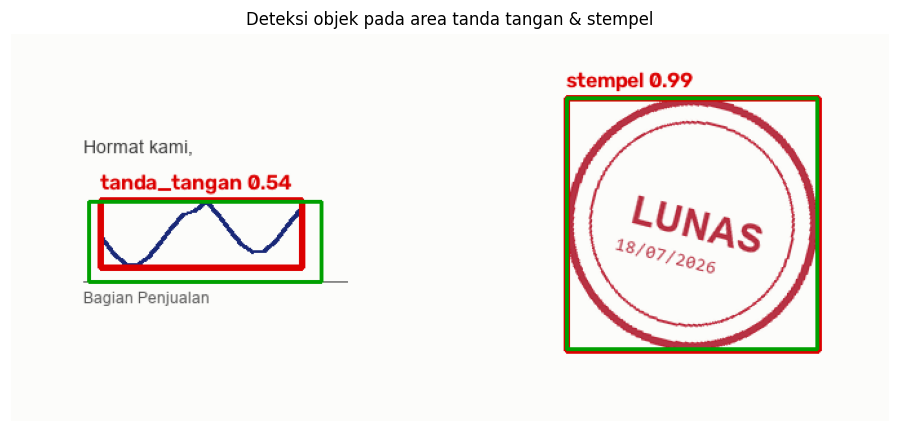

In [9]:
def deteksi_warna_tinta(citra, rentang_hsv, label, luas_min=1200):
    hsv = cv2.cvtColor(citra, cv2.COLOR_BGR2HSV)
    topeng = None
    for bawah, atas in rentang_hsv:
        bagian = cv2.inRange(hsv, np.array(bawah), np.array(atas))
        topeng = bagian if topeng is None else cv2.bitwise_or(topeng, bagian)
    inti = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
    topeng = cv2.morphologyEx(topeng, cv2.MORPH_CLOSE, inti)
    kontur, _ = cv2.findContours(topeng, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    deteksi = []
    for k in kontur:
        luas = cv2.contourArea(k)
        if luas < luas_min:
            continue
        x, y, l, t = cv2.boundingRect(k)
        kepadatan = luas / max(1.0, l * t)
        # Keyakinan sederhana: gabungan ukuran relatif dan kepadatan piksel tinta
        keyakinan = float(np.clip(0.45 + 0.9 * kepadatan + min(luas / 40000.0, 0.25), 0, 0.99))
        deteksi.append({"label": label, "kotak": (x, y, l, t),
                        "keyakinan": round(keyakinan, 3)})
    return deteksi, topeng


MERAH = [((0, 70, 50), (10, 255, 255)), ((170, 70, 50), (180, 255, 255))]
BIRU = [((100, 80, 40), (135, 255, 255))]

deteksi_stempel, topeng_merah = deteksi_warna_tinta(dokumen, MERAH, "stempel", 1500)
deteksi_ttd, topeng_biru = deteksi_warna_tinta(dokumen, BIRU, "tanda_tangan", 400)
deteksi = deteksi_stempel + deteksi_ttd

tanda = dokumen.copy()
for d in deteksi:
    x, y, l, t = d["kotak"]
    cv2.rectangle(tanda, (x, y), (x + l, y + t), (0, 0, 220), 3)
    cv2.putText(tanda, f'{d["label"]} {d["keyakinan"]:.2f}', (x, max(20, y - 8)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 220), 2)
for nama, (x, y, l, t) in meta["kotak"].items():
    cv2.rectangle(tanda, (x, y), (x + l, y + t), (0, 160, 0), 2)

print("Deteksi (merah) vs acuan (hijau):")
for d in deteksi:
    print(" ", d)
tampil(tanda[700:1000, 40:720], "Deteksi objek pada area tanda tangan & stempel", ukuran=(9, 4))

## 7. IoU dan non-maximum suppression

**IoU** (*Intersection over Union*) mengukur seberapa tepat letak kotak prediksi terhadap
kotak acuan: luas irisan dibagi luas gabungan. Nilai 1 berarti berimpit sempurna;
ambang 0,5 lazim dipakai sebagai batas "deteksi benar".

**NMS** (*non-maximum suppression*) membereskan masalah sebaliknya: satu objek sering
menghasilkan banyak kotak bertumpuk. NMS menyimpan kotak berskor tertinggi dan membuang
tetangganya yang beririsan terlalu banyak.

IoU contoh manual = 0.391
Kotak sebelum NMS : 18
Kotak setelah NMS : 1


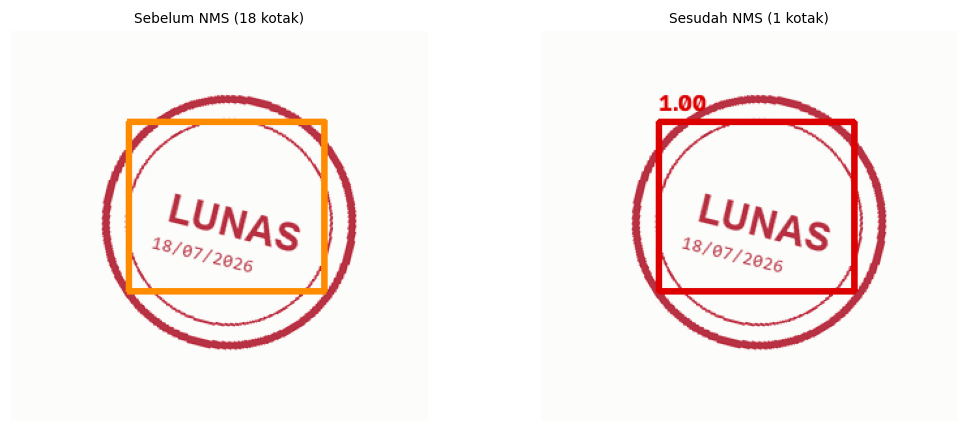

In [10]:
def iou(kotak_a, kotak_b):
    ax, ay, al, at = kotak_a
    bx, by, bl, bt = kotak_b
    x1, y1 = max(ax, bx), max(ay, by)
    x2, y2 = min(ax + al, bx + bl), min(ay + at, by + bt)
    if x2 <= x1 or y2 <= y1:
        return 0.0
    irisan = (x2 - x1) * (y2 - y1)
    gabungan = al * at + bl * bt - irisan
    return irisan / gabungan


def nms(kotak, skor, ambang_iou=0.35):
    urut = sorted(range(len(kotak)), key=lambda i: skor[i], reverse=True)
    disimpan = []
    while urut:
        kini = urut.pop(0)
        disimpan.append(kini)
        urut = [i for i in urut if iou(kotak[kini], kotak[i]) < ambang_iou]
    return disimpan


# Contoh IoU pada dua kotak yang dibuat manual
a, b = (100, 100, 200, 120), (150, 130, 200, 120)
print(f"IoU contoh manual = {iou(a, b):.3f}")

# Kasus nyata: pencocokan template menghasilkan banyak kotak bertumpuk
template = dokumen[770:900, 490:640]
abu_dok = cv2.cvtColor(dokumen, cv2.COLOR_BGR2GRAY)
abu_tpl = cv2.cvtColor(template, cv2.COLOR_BGR2GRAY)
peta = cv2.matchTemplate(abu_dok, abu_tpl, cv2.TM_CCOEFF_NORMED)
posisi = np.argwhere(peta >= 0.55)
kotak_mentah = [(int(x), int(y), abu_tpl.shape[1], abu_tpl.shape[0]) for y, x in posisi]
skor_mentah = [float(peta[y, x]) for y, x in posisi]
print(f"Kotak sebelum NMS : {len(kotak_mentah)}")

pilih = nms(kotak_mentah, skor_mentah, ambang_iou=0.3)
print(f"Kotak setelah NMS : {len(pilih)}")

sebelum, sesudah = dokumen.copy(), dokumen.copy()
for (x, y, l, t) in kotak_mentah:
    cv2.rectangle(sebelum, (x, y), (x + l, y + t), (0, 140, 255), 1)
for i in pilih:
    x, y, l, t = kotak_mentah[i]
    cv2.rectangle(sesudah, (x, y), (x + l, y + t), (0, 0, 220), 3)
    cv2.putText(sesudah, f"{skor_mentah[i]:.2f}", (x, max(20, y - 8)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 220), 2)

tampil_banyak([(f"Sebelum NMS ({len(kotak_mentah)} kotak)", sebelum[700:1000, 400:720]),
               (f"Sesudah NMS ({len(pilih)} kotak)", sesudah[700:1000, 400:720])],
              kolom=2, ukuran=(10, 4))

## 8. Precision, recall, dan F1 untuk deteksi

Dengan IoU sebagai penentu "benar atau salah", kita dapat menghitung metrik yang sama
seperti pada slide *Metrik Akurasi*:

- **Precision** — dari semua yang ditandai sistem, berapa persen yang benar.
- **Recall** — dari semua objek yang sungguh ada, berapa persen yang tertangkap.
- **F1** — rata-rata harmonik keduanya.

Aturannya: satu prediksi dianggap benar (*true positive*) bila labelnya cocok dan IoU
terhadap kotak acuan melewati ambang, serta kotak acuan itu belum dipakai prediksi lain.

detektor  ambang_IoU  TP  FP  FN  precision  recall  F1
 presisi         0.3   2   0   0        1.0     1.0 1.0
   kasar         0.3   2   0   0        1.0     1.0 1.0
 presisi         0.5   2   0   0        1.0     1.0 1.0
   kasar         0.5   1   1   1        0.5     0.5 0.5
 presisi         0.7   2   0   0        1.0     1.0 1.0
   kasar         0.7   0   2   2        0.0     0.0 0.0


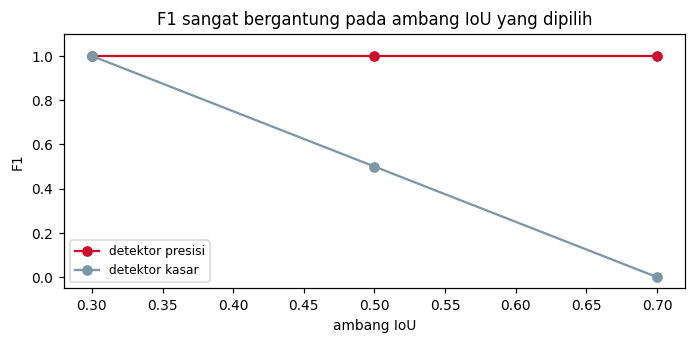

,label,keyakinan,iou_terbaik,status
0,stempel,0.891,0.566,benar
1,tanda_tangan,0.482,0.409,salah tandai


In [11]:
def cocokkan_deteksi(prediksi, acuan, ambang_iou=0.5):
    terpakai, tp, rincian = set(), 0, []
    for p in sorted(prediksi, key=lambda d: d["keyakinan"], reverse=True):
        terbaik_iou, terbaik_nama = 0.0, None
        for nama, kotak in acuan.items():
            if nama in terpakai or nama != p["label"]:
                continue
            nilai = iou(p["kotak"], kotak)
            if nilai > terbaik_iou:
                terbaik_iou, terbaik_nama = nilai, nama
        cocok = terbaik_iou >= ambang_iou and terbaik_nama is not None
        if cocok:
            terpakai.add(terbaik_nama)
            tp += 1
        rincian.append({"label": p["label"], "keyakinan": p["keyakinan"],
                        "iou_terbaik": round(terbaik_iou, 3),
                        "status": "benar" if cocok else "salah tandai"})
    fp = len(prediksi) - tp
    fn = len(acuan) - tp
    precision = tp / max(1, tp + fp)
    recall = tp / max(1, tp + fn)
    f1 = 0.0 if precision + recall == 0 else 2 * precision * recall / (precision + recall)
    return {"TP": tp, "FP": fp, "FN": fn,
            "precision": round(precision, 3), "recall": round(recall, 3),
            "F1": round(f1, 3)}, pd.DataFrame(rincian)


def perkasar(deteksi_asli, geser=0.20, susut=0.75):
    # Meniru detektor yang letaknya kurang presisi: kotak digeser dan diperkecil
    kasar = []
    for d in deteksi_asli:
        x, y, l, t = d["kotak"]
        kasar.append({**d,
                      "kotak": (x + int(l * geser), y + int(t * geser),
                                int(l * susut), int(t * susut)),
                      "keyakinan": round(d["keyakinan"] * 0.9, 3)})
    return kasar


deteksi_kasar = perkasar(deteksi)

catatan_ambang = []
for ambang in (0.3, 0.5, 0.7):
    for nama, kumpulan in (("presisi", deteksi), ("kasar", deteksi_kasar)):
        ringkas, _ = cocokkan_deteksi(kumpulan, meta["kotak"], ambang_iou=ambang)
        catatan_ambang.append({"detektor": nama, "ambang_IoU": ambang, **ringkas})

tabel_ambang = pd.DataFrame(catatan_ambang)
print(tabel_ambang.to_string(index=False))

fig, ax = plt.subplots(figsize=(6.4, 3.2))
for nama, warna in (("presisi", "#CE0E2D"), ("kasar", "#7C97A6")):
    bagian = tabel_ambang[tabel_ambang["detektor"] == nama]
    ax.plot(bagian["ambang_IoU"], bagian["F1"], marker="o", label=f"detektor {nama}", color=warna)
ax.set_xlabel("ambang IoU")
ax.set_ylabel("F1")
ax.set_ylim(-0.05, 1.1)
ax.set_title("F1 sangat bergantung pada ambang IoU yang dipilih")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

_, rincian = cocokkan_deteksi(deteksi_kasar, meta["kotak"], ambang_iou=0.5)
rincian

Detektor "presisi" dan "kasar" menghasilkan **jumlah deteksi yang persis sama** — yang
berbeda hanya ketepatan letak kotaknya. Namun F1-nya berbeda jauh begitu ambang IoU
dinaikkan.

Pelajaran praktisnya: setiap kali seseorang melaporkan akurasi deteksi, tanyakan pada
ambang IoU berapa angka itu dihitung. Tanpa informasi tersebut, angka akurasi dari dua
sistem tidak dapat dibandingkan.

## 9. Latihan mandiri

1. **Pasca-pemrosesan.** Tulis fungsi `koreksi_nomor(teks)` yang memperbaiki kesalahan
   khas pada nomor faktur: huruf `O` menjadi angka `0`, huruf `l` menjadi angka `1`,
   tetapi hanya di dalam pola `INV/…`. Ukur ulang CER setelah koreksi.
2. **Ambang keyakinan.** Cari nilai `AMBANG_KATA` terkecil yang masih menangkap seluruh
   kata salah baca pada dokumen ini. Apa dampaknya terhadap beban tinjauan manusia?
3. **Segmentasi.** Ubah `lebar_inti` pada `deteksi_area_teks` menjadi 5, 15, dan 45.
   Jelaskan mengapa jumlah blok yang terdeteksi berubah.
4. **Deteksi objek.** Buat dokumen tanpa stempel (`buat_dokumen(pakai_stempel=False)`),
   jalankan ulang bagian 6 dan 8, lalu amati bagaimana recall berubah.

In [12]:
# Kerangka jawaban latihan 1 — silakan lengkapi
def koreksi_nomor(teks):
    def perbaiki(cocok):
        nomor = cocok.group(0)
        # TODO: ganti O -> 0 dan l -> 1 hanya pada bagian angka setelah "INV/"
        return nomor

    return re.sub(r"INV/\S+", perbaiki, teks)


contoh_salah = "No. Faktur : 1NV/2O26/O7/OO184"
print("sebelum:", contoh_salah)
print("sesudah:", koreksi_nomor(contoh_salah))
print("CER sebelum koreksi:", round(hitung_cer(TEKS_ACUAN.splitlines()[0], contoh_salah), 3))

sebelum: No. Faktur : 1NV/2O26/O7/OO184
sesudah: No. Faktur : 1NV/2O26/O7/OO184
CER sebelum koreksi: 0.167


## Ringkasan

- OCR mengembalikan **teks dan skor keyakinan**. Skor keyakinan adalah bahan baku
  keputusan otomatis pada Materi 4; jangan dibuang.
- Lima tahap OCR dapat dibongkar: deteksi area, segmentasi, normalisasi, pengenalan,
  pasca-pemrosesan. Mengetahui tahap mana yang gagal membuat perbaikan jauh lebih terarah.
- CER dan WER dihitung dari jarak edit terhadap teks acuan. Tanpa teks acuan, akurasi
  tidak bisa diklaim.
- Pra-pemrosesan yang tepat menurunkan CER secara nyata pada citra bermasalah.
- Deteksi objek menghasilkan label, kotak, dan keyakinan. IoU menilai ketepatan letak,
  NMS merapikan kotak bertumpuk, dan precision/recall/F1 merangkum mutunya.

**Lanjut ke:** `03_validasi_dokumen_otomatis.ipynb` — mengubah hasil baca menjadi
keputusan bisnis yang dapat dipertanggungjawabkan.